In [2]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_air_passengers
from src.feature_engineering import create_lag_features, get_feature_target_columns
from src.models import train_linear_regression, train_random_forest
from src.evaluate import evaluate_model, compare_models

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
%matplotlib inline

In [3]:
df = load_air_passengers()
df_features = create_lag_features(df, n_lags=12)
feature_cols, target_col = get_feature_target_columns(df_features)

print(f"Feature columns ({len(feature_cols)}): {feature_cols}")
print(f"Target column: {target_col}")
print(f"Total samples after lag creation: {len(df_features)}")
df_features.head()


Feature columns (12): ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12']
Target column: value
Total samples after lag creation: 132


,value,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12
date,,,,,,,,,,,,,
1950-01-01,115,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0,132.0,118.0,112.0
1950-02-01,126,115.0,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0,132.0,118.0
1950-03-01,141,126.0,115.0,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0,132.0
1950-04-01,135,141.0,126.0,115.0,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0
1950-05-01,125,135.0,141.0,126.0,115.0,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0


In [4]:
X = df_features[feature_cols]
y = df_features[target_col]

X_train = X.iloc[:-12]
X_test = X.iloc[-12:]
y_train = y.iloc[:-12]
y_test = y.iloc[-12:]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")
print(f"\nTrain period: {X_train.index.min()} to {X_train.index.max()}")
print(f"Test period:  {X_test.index.min()} to {X_test.index.max()}")

X_train: (120, 12), y_train: (120,)
X_test:  (12, 12), y_test:  (12,)

Train period: 1950-01-01 00:00:00 to 1959-12-01 00:00:00
Test period:  1960-01-01 00:00:00 to 1960-12-01 00:00:00


In [5]:
lr_model = train_linear_regression(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
lr_results = evaluate_model(y_test, y_pred_lr, "Linear Regression")

Linear Regression — MAE: 17.19, RMSE: 20.76


In [6]:
rf_model = train_random_forest(X_train, y_train, n_estimators=100, random_state=42)
y_pred_rf = rf_model.predict(X_test)
rf_results = evaluate_model(y_test, y_pred_rf, "Random Forest")

Random Forest — MAE: 28.99, RMSE: 38.17


In [7]:
results = {
    'Linear Regression': lr_results,
    'Random Forest': rf_results,
}
compare_models(results)


Model                     MAE     RMSE
Linear Regression       17.19    20.76
Random Forest           28.99    38.17


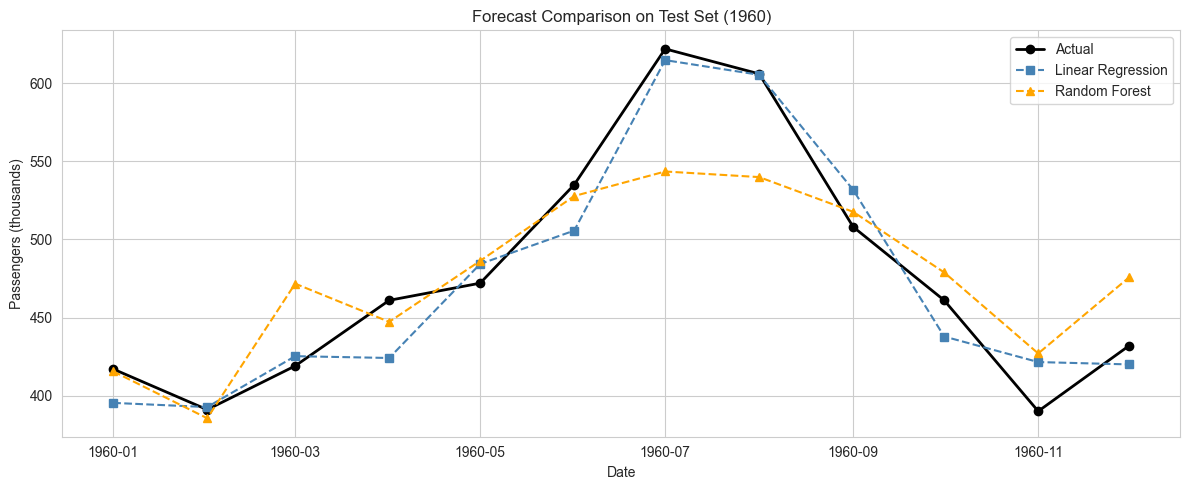

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(y_test.index, y_test.values, 'o-', label='Actual',
        color='black', linewidth=2, markersize=6)
ax.plot(y_test.index, y_pred_lr, 's--', label='Linear Regression',
        color='steelblue', linewidth=1.5)
ax.plot(y_test.index, y_pred_rf, '^--', label='Random Forest',
        color='orange', linewidth=1.5)

ax.set_title('Forecast Comparison on Test Set (1960)')
ax.set_xlabel('Date')
ax.set_ylabel('Passengers (thousands)')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/05_forecast_comparison.png', dpi=150)
plt.show()

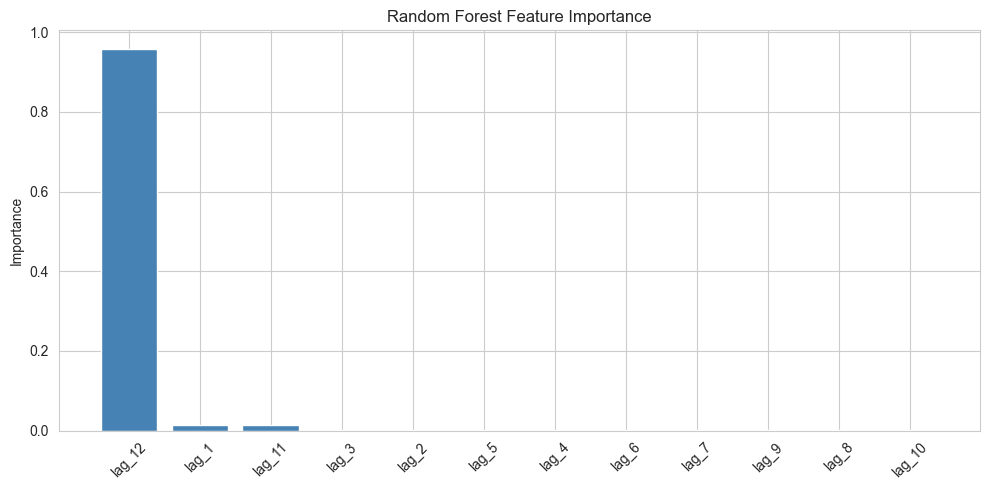

In [9]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(importances)), importances[indices], color='steelblue')
ax.set_xticks(range(len(importances)))
ax.set_xticklabels([feature_cols[i] for i in indices], rotation=45)
ax.set_title('Random Forest Feature Importance')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.savefig('../results/figures/06_feature_importance.png', dpi=150)
plt.show()


In [10]:
import json
import os

os.makedirs('../results', exist_ok=True)
with open('../results/model_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Results saved.")
print(json.dumps(results, indent=2))


Results saved.
{
  "Linear Regression": {
    "mae": 17.19302755499066,
    "rmse": 20.761455042274594
  },
  "Random Forest": {
    "mae": 28.985833333333332,
    "rmse": 38.16536136778131
  }
}


## Analysis of Results

| Model | MAE | RMSE |
|:---|:---|:---|
| Linear Regression | 17.19 | 20.76 |
| Random Forest | 28.99 | 38.17 |

**Linear Regression outperforms Random Forest on this task.**

This is a well-known limitation of tree-based models for time series forecasting:
decision trees are piecewise-constant functions, and therefore **cannot extrapolate**
beyond the range of target values seen during training.

The training set (1950–1959) has a maximum of ~570 passengers, while the test set
(1960) reaches ~622 passengers. The Random Forest is bounded by the training range
and systematically underpredicts. Linear Regression, in contrast, learns a linear
combination of lag features and can extend beyond the observed range.

This demonstrates that **model selection must consider the mathematical properties
of the data** — trend and non-stationarity, in this case — not just model complexity.